# FraudeShield — Détection de Fraude sur Données Réelles (Kaggle)

**Dataset** : [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) — ULB Machine Learning Group  
Transactions par carte bancaire de septembre 2013 (porteurs européens).

| | |
|---|---|
| Transactions | 284 807 |
| Fraudes | 492 (0.172%) |
| Features | V1–V28 (PCA anonymisés) + Amount + Time |
| Problème | Classification binaire extrêmement déséquilibrée |

## 0. Imports

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
plt.rcParams['figure.dpi'] = 110
print('OK')

OK


---
## 1. Chargement des données

In [6]:
df = pd.read_csv('data/creditcard.csv')

print(f"Shape          : {df.shape}")
print(f"Fraudes        : {df['Class'].sum()} ({df['Class'].mean()*100:.3f}%)")
print(f"Transactions   : {len(df):,}")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
df.head()

Shape          : (284807, 31)
Fraudes        : 492 (0.173%)
Transactions   : 284,807
Valeurs nulles : 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 2. Analyse Exploratoire (EDA)

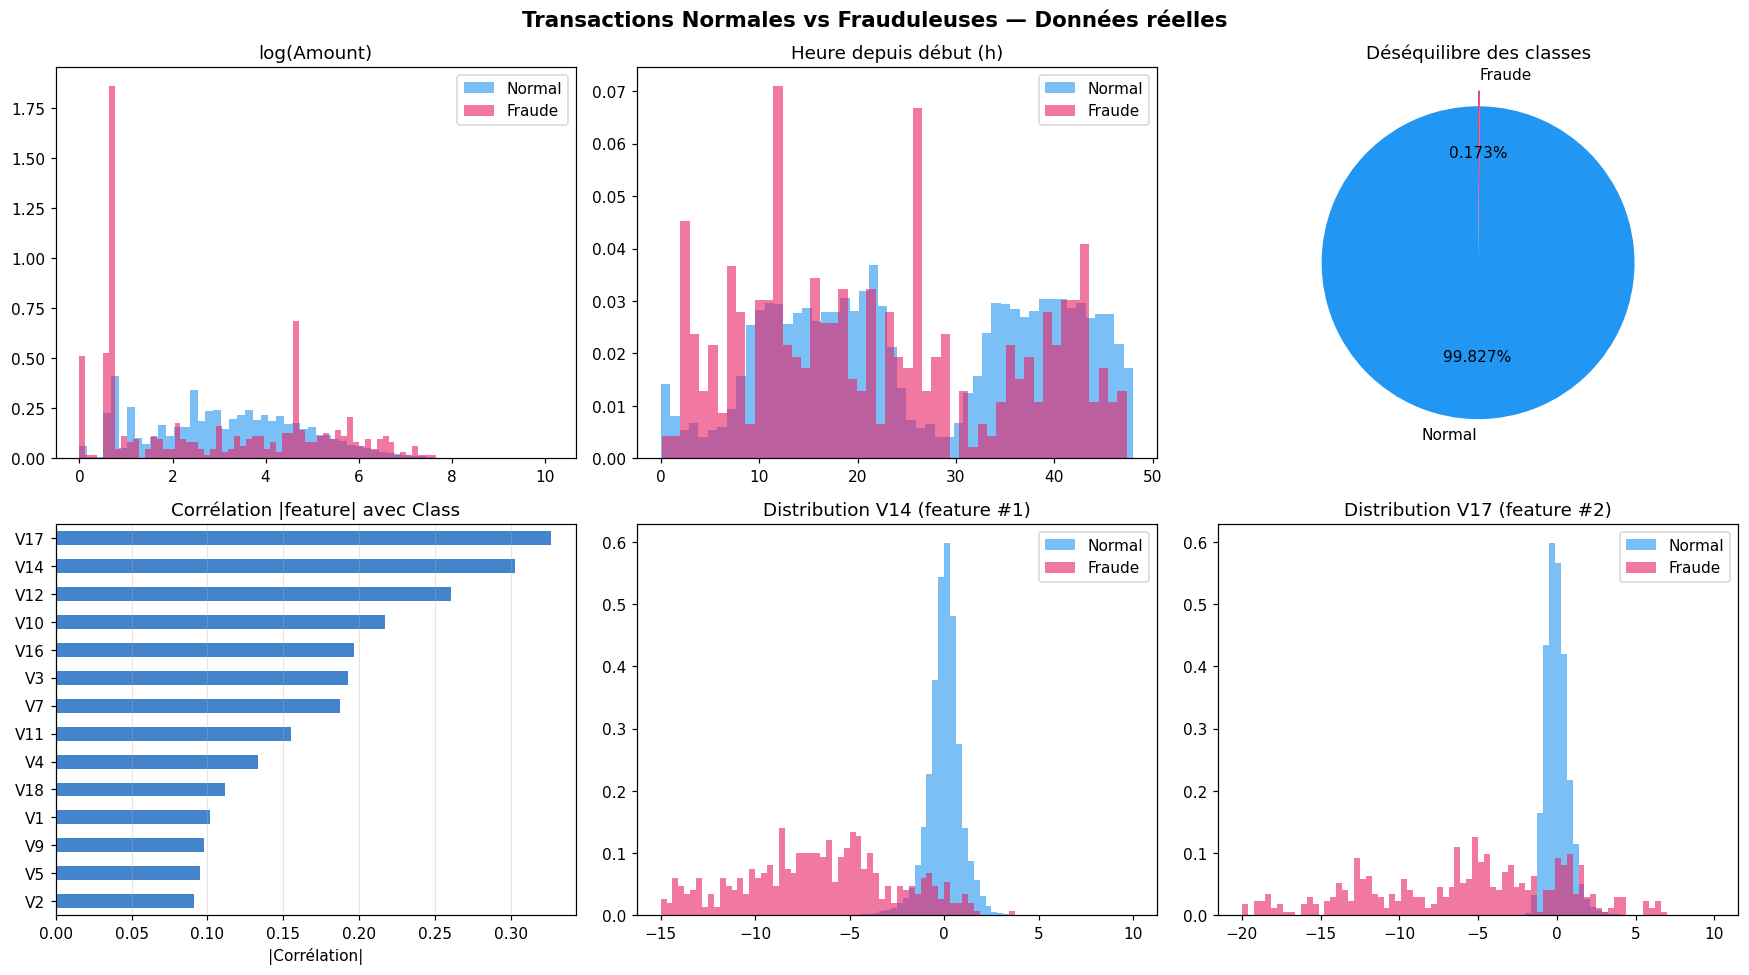

In [7]:
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Transactions Normales vs Frauduleuses — Données réelles', fontsize=14, fontweight='bold')

# Montant
ax = axes[0, 0]
ax.hist(np.log1p(normal['Amount']), bins=60, alpha=0.6, color='#2196F3', label='Normal', density=True)
ax.hist(np.log1p(fraud['Amount']),  bins=60, alpha=0.6, color='#E91E63', label='Fraude', density=True)
ax.set_title('log(Amount)'); ax.legend()

# Temps
ax = axes[0, 1]
ax.hist(normal['Time'] / 3600, bins=50, alpha=0.6, color='#2196F3', label='Normal', density=True)
ax.hist(fraud['Time'] / 3600,  bins=50, alpha=0.6, color='#E91E63', label='Fraude', density=True)
ax.set_title('Heure depuis début (h)'); ax.legend()

# Déséquilibre
ax = axes[0, 2]
counts = df['Class'].value_counts()
ax.pie(counts, labels=['Normal', 'Fraude'], colors=['#2196F3', '#E91E63'],
       autopct='%1.3f%%', startangle=90, explode=(0, 0.1))
ax.set_title('Déséquilibre des classes')

# Features PCA les plus discriminantes (corrélation avec Class)
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = corr.head(10).index.tolist()

ax = axes[1, 0]
corr.head(14).plot(kind='barh', ax=ax, color='#1565C0', alpha=0.8)
ax.set_title('Corrélation |feature| avec Class')
ax.set_xlabel('|Corrélation|')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Distribution de V14 (feature la plus discriminante)
ax = axes[1, 1]
ax.hist(normal['V14'], bins=80, alpha=0.6, color='#2196F3', label='Normal', density=True, range=(-15, 10))
ax.hist(fraud['V14'],  bins=80, alpha=0.6, color='#E91E63', label='Fraude', density=True, range=(-15, 10))
ax.set_title('Distribution V14 (feature #1)'); ax.legend()

# Distribution de V17
ax = axes[1, 2]
ax.hist(normal['V17'], bins=80, alpha=0.6, color='#2196F3', label='Normal', density=True, range=(-20, 10))
ax.hist(fraud['V17'],  bins=80, alpha=0.6, color='#E91E63', label='Fraude', density=True, range=(-20, 10))
ax.set_title('Distribution V17 (feature #2)'); ax.legend()

plt.tight_layout()
plt.show()

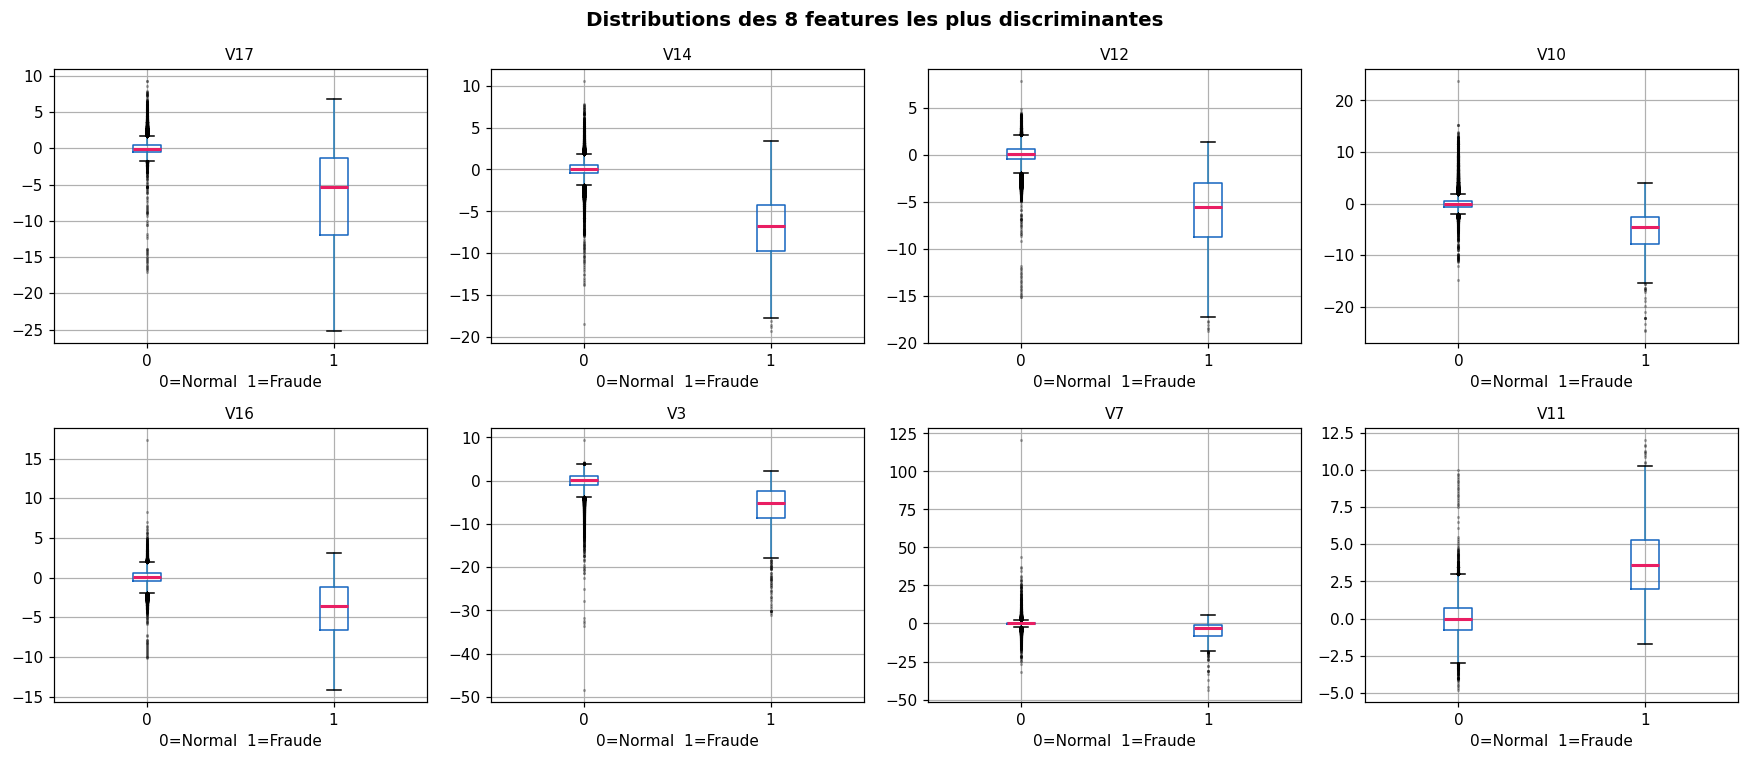

In [8]:
# Boxplots des 8 features les plus discriminantes
top8 = corr.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Distributions des 8 features les plus discriminantes', fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, top8):
    df.boxplot(column=feat, by='Class', ax=ax,
               boxprops=dict(color='#1565C0'),
               medianprops=dict(color='#E91E63', lw=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('0=Normal  1=Fraude')
    plt.suptitle('')

fig.suptitle('Distributions des 8 features les plus discriminantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

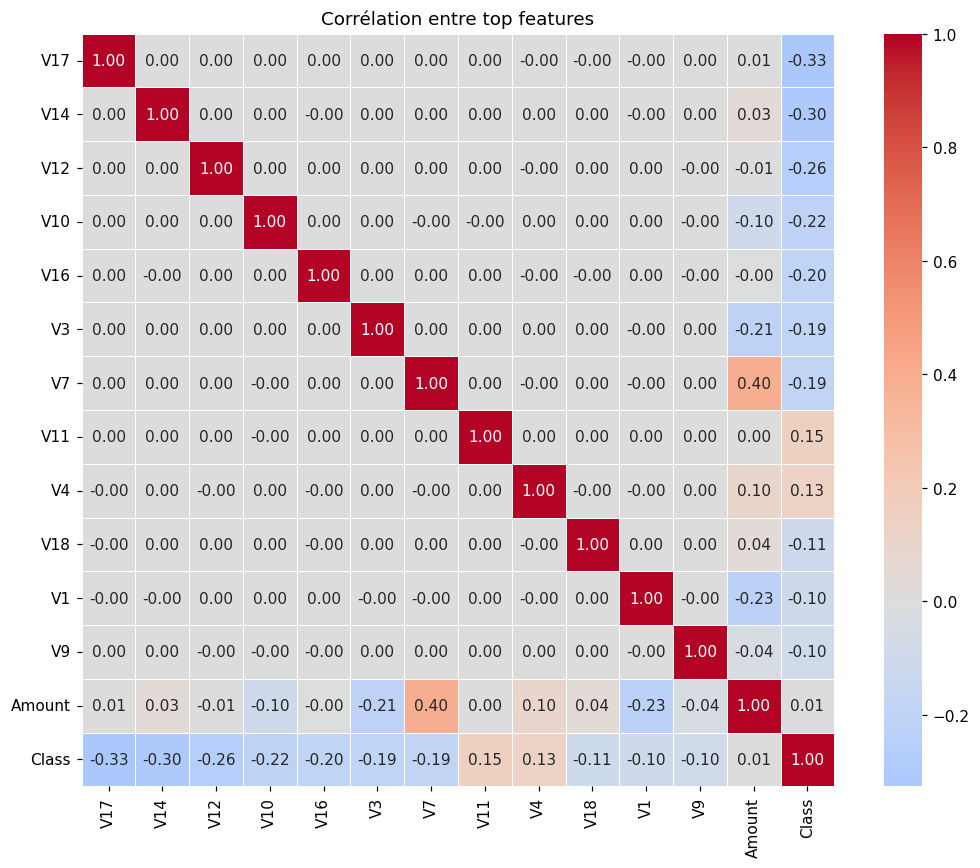

In [9]:
# Matrice de corrélation sur les top features
top12 = corr.head(12).index.tolist() + ['Amount', 'Class']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[top12].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Corrélation entre top features')
plt.tight_layout()
plt.show()

---
## 3. Prétraitement

- `Amount` et `Time` ne sont pas standardisés (contrairement aux V1–V28 déjà PCA) → on les normalise
- On ajoute `Amount_log = log(1 + Amount)`
- Split stratifié 80/20

In [10]:
df_proc = df.copy()

# Feature engineering
df_proc['Amount_log'] = np.log1p(df_proc['Amount'])
df_proc['Hour']       = (df_proc['Time'] % 86400) / 3600   # heure dans la journée
df_proc = df_proc.drop(columns=['Time'])                    # Time brut peu utile

X = df_proc.drop(columns=['Class'])
y = df_proc['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normaliser Amount et Amount_log (les Vx sont déjà centrés)
cols_to_scale = ['Amount', 'Amount_log', 'Hour']
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(f"Train : {len(X_train):,} samples  |  Test : {len(X_test):,} samples")
print(f"Fraudes train : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraudes test  : {y_test.sum()} ({y_test.mean()*100:.3f}%)")
print(f"Features : {X_train.shape[1]}")

Train : 227,845 samples  |  Test : 56,962 samples
Fraudes train : 394 (0.173%)
Fraudes test  : 98 (0.172%)
Features : 31


---
## 4. Définition des modèles

Tous avec `class_weight='balanced'` pour compenser le déséquilibre extrême (1 fraude pour 578 normales).

In [11]:
models = {
    "Regression Logistique": LogisticRegression(
        C=0.01, class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, class_weight='balanced',
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        subsample=0.8, random_state=42
    ),
    "Reseau de Neurones": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu', alpha=0.01,
        max_iter=200, early_stopping=True, validation_fraction=0.1, random_state=42
    ),
}
print(f"{len(models)} modeles definis.")

4 modeles definis.


---
## 5. Cross-Validation (5-fold, AUC-PR)

Sur données très déséquilibrées, on préfère l'**AUC-PR** (Précision-Rappel) à l'AUC-ROC comme métrique principale.

Regression Logistique      AUC-PR = 0.5507 +/- 0.1618
Random Forest              AUC-PR = 0.7388 +/- 0.1746
Gradient Boosting          AUC-PR = 0.5490 +/- 0.2295
Reseau de Neurones         AUC-PR = 0.2553 +/- 0.2264


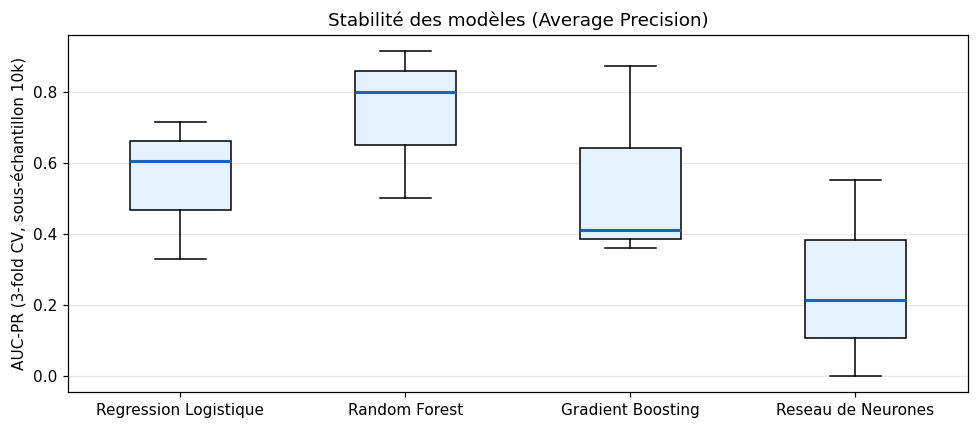

In [12]:
# CV sur sous-échantillon stratifié (10k samples, ~17 fraudes)
# Le Gradient Boosting est trop lent sur 228k samples × 5 folds
_, X_cv, _, y_cv = train_test_split(X_train, y_train, test_size=10000,
                                     random_state=42, stratify=y_train)

models_cv = {
    "Regression Logistique": LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=30, learning_rate=0.1, max_depth=4, random_state=42),
    "Reseau de Neurones":     MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, early_stopping=True, random_state=42),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = {}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  AUC-PR = {scores.mean():.4f} +/- {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([cv_results[n] for n in models_cv], labels=list(models_cv.keys()),
           patch_artist=True, boxprops=dict(facecolor='#E3F2FD'),
           medianprops=dict(color='#1565C0', lw=2))
ax.set_ylabel('AUC-PR (3-fold CV, sous-échantillon 10k)')
ax.set_title('Stabilité des modèles (Average Precision)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Entraînement final et Évaluation

In [13]:
trained = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    r = {
        'model':     name,
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
        'AUC-PR':    round(average_precision_score(y_test, y_proba), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Rappel':    round(recall_score(y_test, y_pred), 4),
        'y_pred':    y_pred,
        'y_proba':   y_proba,
    }
    results.append(r)
    print(f"{name:25s}  AUC-ROC={r['AUC-ROC']}  AUC-PR={r['AUC-PR']}  F1={r['F1']}  Rappel={r['Rappel']}")

summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ('y_pred','y_proba')}
                         for r in results]).sort_values('AUC-PR', ascending=False)
summary

Regression Logistique      AUC-ROC=0.9712  AUC-PR=0.7184  F1=0.1071  Rappel=0.9082
Random Forest              AUC-ROC=0.9752  AUC-PR=0.8433  F1=0.8205  Rappel=0.8163
Gradient Boosting          AUC-ROC=0.5102  AUC-PR=0.3348  F1=0.5478  Rappel=0.4388
Reseau de Neurones         AUC-ROC=0.9815  AUC-PR=0.8154  F1=0.8367  Rappel=0.8367


,model,AUC-ROC,AUC-PR,F1,Precision,Rappel
1,Random Forest,0.9752,0.8433,0.8205,0.8247,0.8163
3,Reseau de Neurones,0.9815,0.8154,0.8367,0.8367,0.8367
0,Regression Logistique,0.9712,0.7184,0.1071,0.0569,0.9082
2,Gradient Boosting,0.5102,0.3348,0.5478,0.7288,0.4388


---
## 7. Courbes ROC et Précision-Rappel

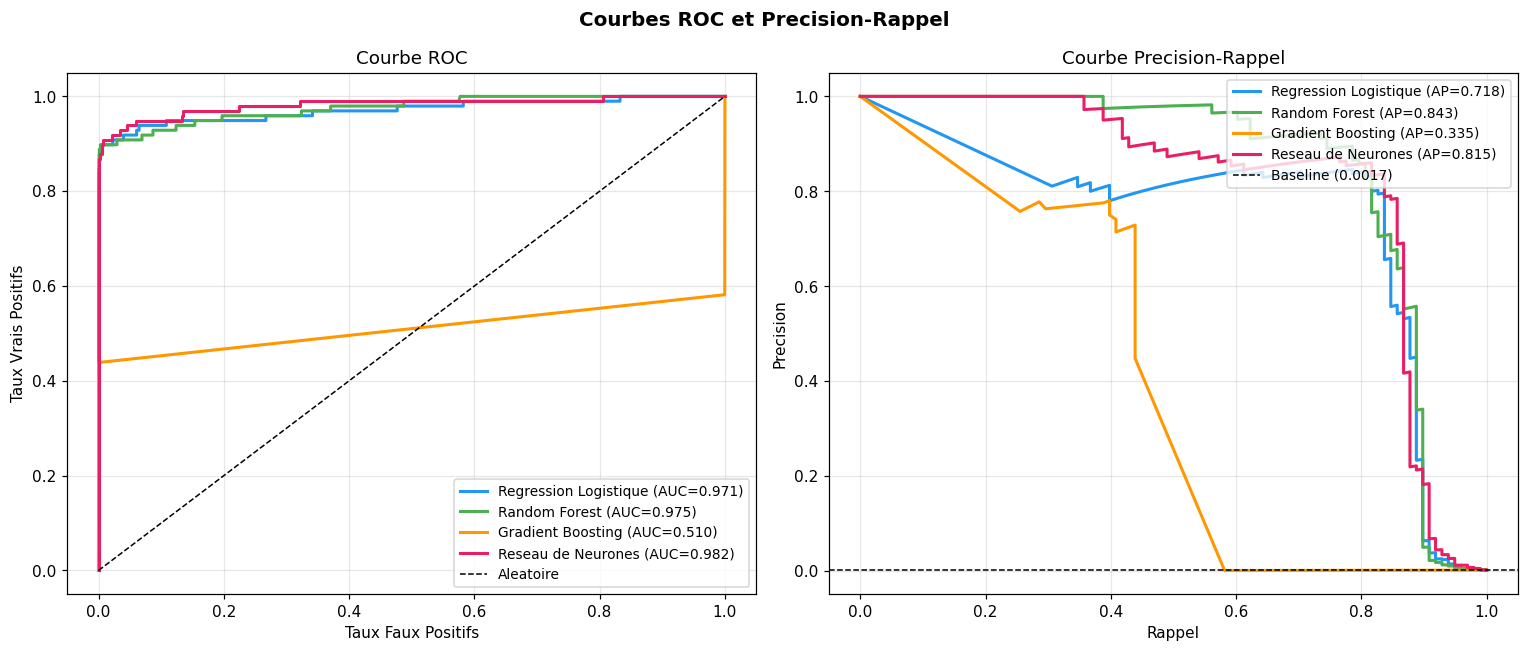

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Courbes ROC et Precision-Rappel', fontsize=13, fontweight='bold')

for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, color=COLORS[i], lw=2, label=f"{r['model']} (AUC={r['AUC-ROC']:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax2.plot(rec, prec, color=COLORS[i], lw=2, label=f"{r['model']} (AP={r['AUC-PR']:.3f})")

ax1.plot([0,1],[0,1],'k--',lw=1,label='Aleatoire')
ax1.set(xlabel='Taux Faux Positifs', ylabel='Taux Vrais Positifs', title='Courbe ROC')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

baseline = y_test.mean()
ax2.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline ({baseline:.4f})')
ax2.set(xlabel='Rappel', ylabel='Precision', title='Courbe Precision-Rappel')
ax2.legend(fontsize=9, loc='upper right'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Matrices de Confusion

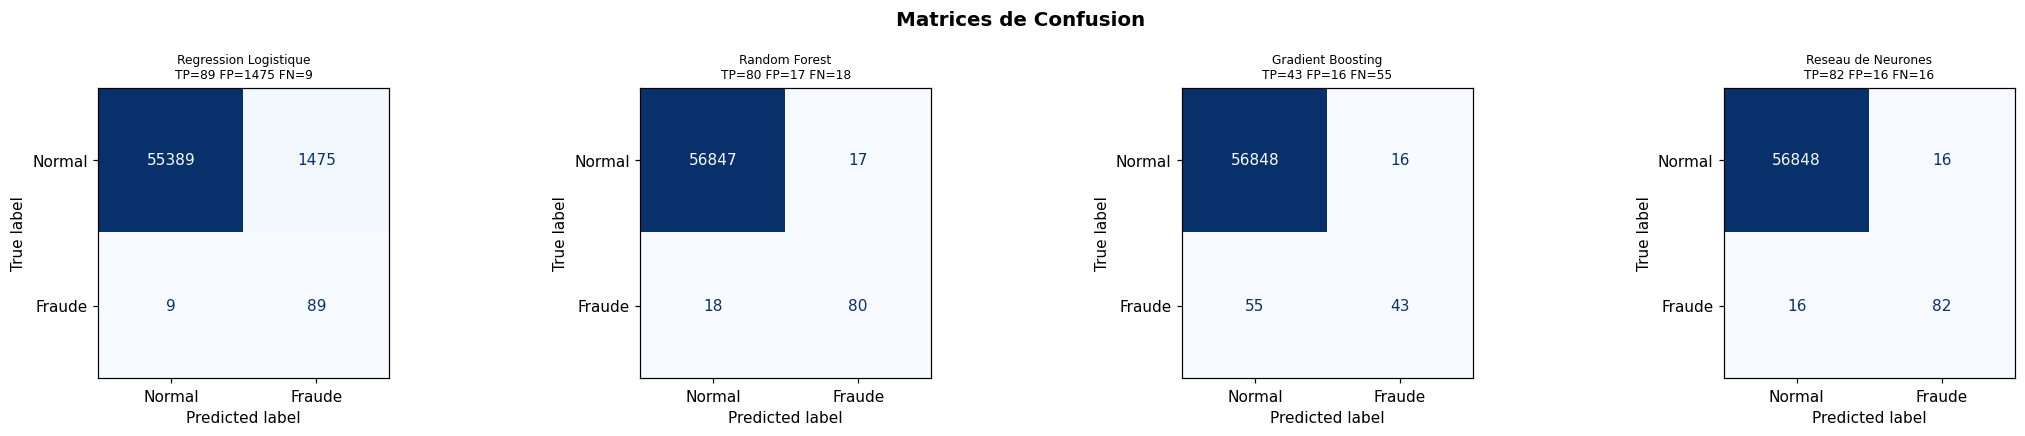

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Matrices de Confusion', fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraude']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{r['model']}\nTP={tp} FP={fp} FN={fn}", fontsize=8)

plt.tight_layout()
plt.show()

---
## 9. Importance des Features

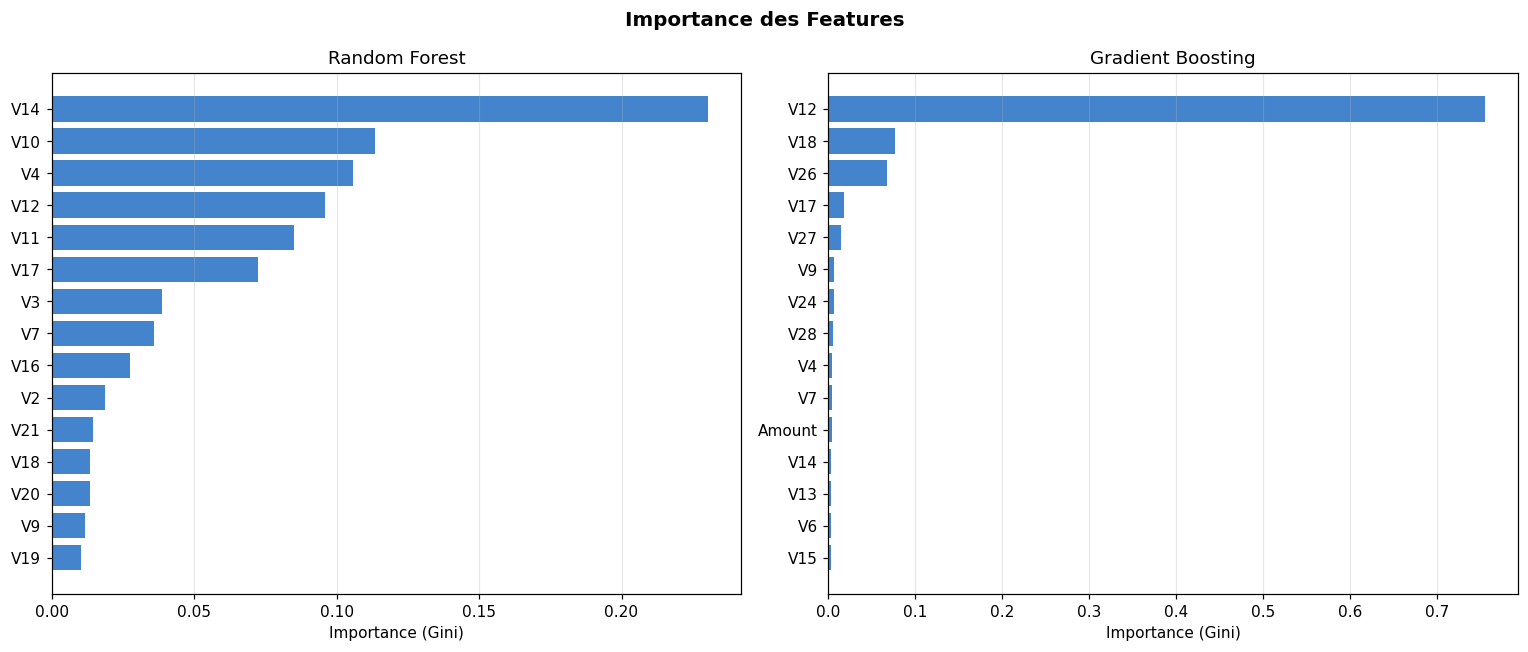

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Importance des Features', fontsize=13, fontweight='bold')

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    imp = pd.Series(trained[name].feature_importances_, index=X_train.columns)
    imp = imp.sort_values(ascending=True).tail(15)
    ax.barh(imp.index, imp.values, color='#1565C0', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Importance (Gini)')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Analyse du Seuil de Décision

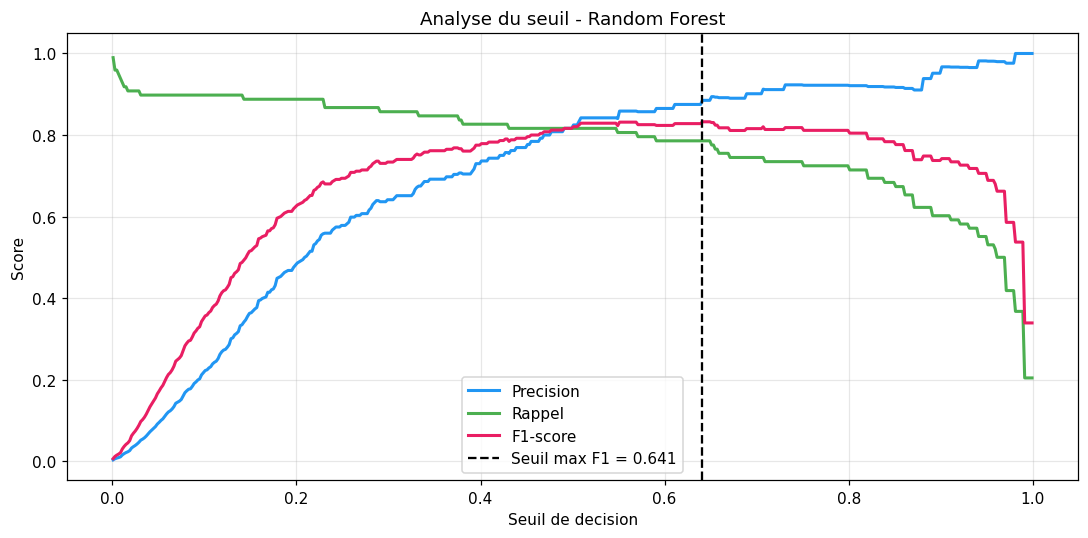

Seuil optimal F1    : 0.641


In [17]:
best = max(results, key=lambda r: r['AUC-PR'])
thresholds = np.linspace(0.001, 0.999, 500)
prec_list, rec_list, f1_list = [], [], []

for t in thresholds:
    yp = (best['y_proba'] >= t).astype(int)
    prec_list.append(precision_score(y_test, yp, zero_division=0))
    rec_list.append(recall_score(y_test, yp, zero_division=0))
    f1_list.append(f1_score(y_test, yp, zero_division=0))

best_t_f1     = thresholds[np.argmax(f1_list)]
# Seuil rappel >= 90%
recall90_idx  = next((i for i, r in enumerate(rec_list) if r >= 0.90), None)
best_t_recall = thresholds[recall90_idx] if recall90_idx else None

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_list, color='#2196F3', lw=2, label='Precision')
ax.plot(thresholds, rec_list,  color='#4CAF50', lw=2, label='Rappel')
ax.plot(thresholds, f1_list,   color='#E91E63', lw=2, label='F1-score')
ax.axvline(best_t_f1, color='black', linestyle='--', label=f'Seuil max F1 = {best_t_f1:.3f}')
if best_t_recall:
    ax.axvline(best_t_recall, color='green', linestyle=':', label=f'Seuil rappel>=90% = {best_t_recall:.3f}')
ax.set(xlabel='Seuil de decision', ylabel='Score',
       title=f'Analyse du seuil - {best["model"]}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Seuil optimal F1    : {best_t_f1:.3f}")
if best_t_recall:
    yp90 = (best['y_proba'] >= best_t_recall).astype(int)
    print(f"Seuil rappel >= 90% : {best_t_recall:.3f}  (Precision={precision_score(y_test, yp90, zero_division=0):.3f}, Rappel={recall_score(y_test, yp90):.3f})")

---
## 11. Analyse Coût-Bénéfice

| Cas | Gain/Perte | Hypothèse |
|---|---|---|
| Fraude détectée (TP) | +800€ − 30€ | Fraude bloquée, investigation 30€ |
| Fraude manquée (FN) | −800€ | Perte totale |
| Fausse alarme (FP) | −30€ | Investigation inutile |

In [18]:
AVG_FRAUD   = 800
INVEST_COST =  30

print(f"{'Modele':25s}  {'TP':>4}  {'FN':>4}  {'FP':>6}  {'Gain net':>11}  {'Economies':>12}")
print('-' * 80)

for r in results:
    cm = confusion_matrix(y_test, r['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    gain_net  = tp*(AVG_FRAUD - INVEST_COST) - fn*AVG_FRAUD - fp*INVEST_COST
    economies = gain_net + (tp + fn)*AVG_FRAUD
    print(f"{r['model']:25s}  {tp:>4}  {fn:>4}  {fp:>6}  {gain_net:>10,.0f}E  {economies:>11,.0f}E")

Modele                       TP    FN      FP     Gain net     Economies
--------------------------------------------------------------------------------
Regression Logistique        89     9    1475      17,080E       95,480E
Random Forest                80    18      17      46,690E      125,090E
Gradient Boosting            43    55      16     -11,370E       67,030E
Reseau de Neurones           82    16      16      49,860E      128,260E


---
## 12. Comparaison finale

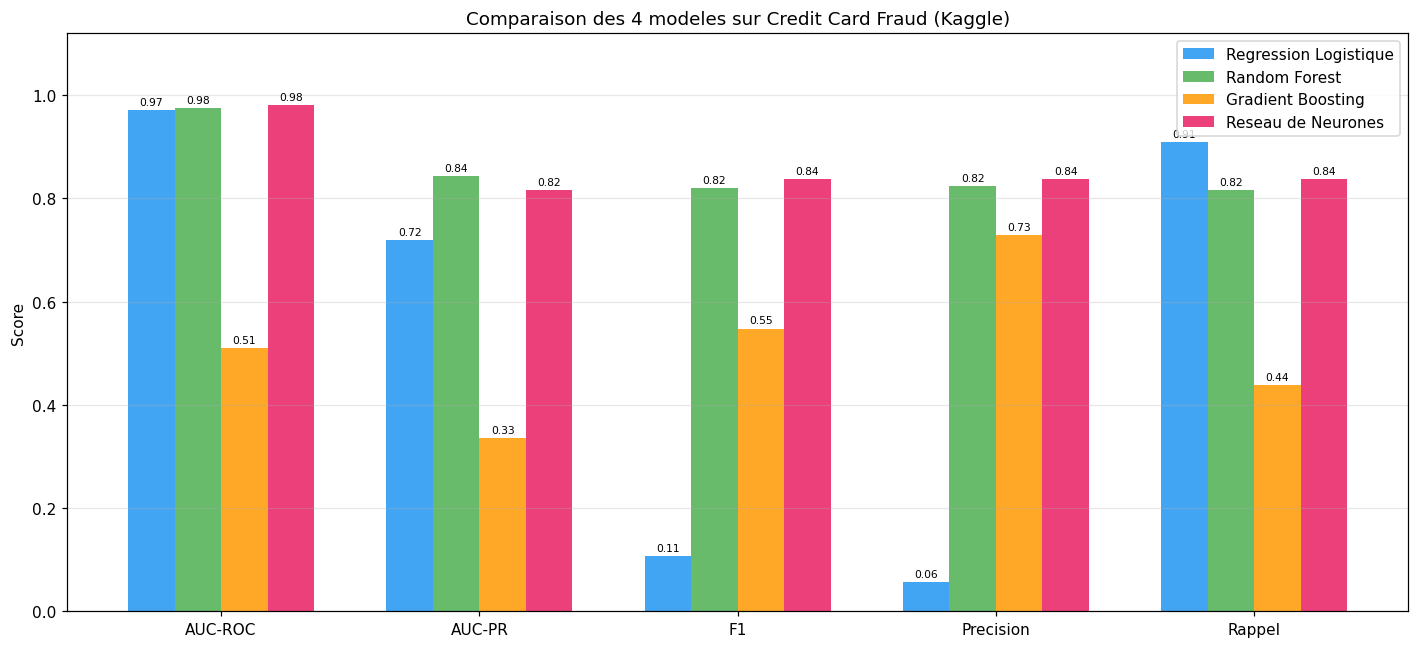


Tableau final (trie par AUC-PR) :


,model,AUC-ROC,AUC-PR,F1,Precision,Rappel
1,Random Forest,0.9752,0.8433,0.8205,0.8247,0.8163
3,Reseau de Neurones,0.9815,0.8154,0.8367,0.8367,0.8367
0,Regression Logistique,0.9712,0.7184,0.1071,0.0569,0.9082
2,Gradient Boosting,0.5102,0.3348,0.5478,0.7288,0.4388


In [19]:
metrics = ['AUC-ROC', 'AUC-PR', 'F1', 'Precision', 'Rappel']
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))
for i, r in enumerate(results):
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=r['model'], color=COLORS[i], alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Comparaison des 4 modeles sur Credit Card Fraud (Kaggle)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTableau final (trie par AUC-PR) :")
summary

---
## 13. (Bonus) Tester le meilleur modèle sur une transaction

In [20]:
best_model = trained[best['model']]
feature_cols = X_train.columns.tolist()

# Prendre une vraie fraude et une vraie transaction normale du test set
idx_fraud  = y_test[y_test == 1].index[0]
idx_normal = y_test[y_test == 0].index[0]

for label, idx in [('Vraie fraude', idx_fraud), ('Vraie transaction normale', idx_normal)]:
    x_row   = X_test.loc[[idx]]
    proba   = best_model.predict_proba(x_row)[0, 1]
    decision = 'FRAUDE DETECTEE' if proba > best_t_f1 else 'NORMALE'
    vrai    = 'FRAUDE' if y_test.loc[idx] == 1 else 'NORMALE'
    ok      = 'OK' if (proba > best_t_f1) == (y_test.loc[idx] == 1) else 'ERREUR'
    print(f"{label:30s}  P(fraude)={proba:.4f}  Decision={decision:18s}  Verite={vrai}  [{ok}]")

Vraie fraude                    P(fraude)=0.9898  Decision=FRAUDE DETECTEE     Verite=FRAUDE  [OK]
Vraie transaction normale       P(fraude)=0.0003  Decision=NORMALE             Verite=NORMALE  [OK]


---
## Extensions possibles

1. **SMOTE** (`pip install imbalanced-learn`) — surééchantillonner les fraudes
2. **SHAP** (`pip install shap`) — expliquer chaque prédiction individuelle  
3. **XGBoost/LightGBM** — souvent les meilleurs sur ce dataset  
4. **Autoencoder** — détection non-supervisée (entraîner uniquement sur les normales)  
5. **API FastAPI** — mettre le modèle en production avec `joblib.dump(model, 'model.pkl')`